Cell 1 – Imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                  random_state=42, stratify=y)

n_labeled = 100
indices = np.random.permutation(len(X_train))
X_labeled = X_train[indices[:n_labeled]]
y_labeled = y_train[indices[:n_labeled]]
X_unlabeled = X_train[indices[n_labeled:]]
y_unlabeled_true = y_train[indices[n_labeled:]]

scaler = StandardScaler()
X_labeled = scaler.fit_transform(X_labeled)
X_unlabeled = scaler.transform(X_unlabeled)
X_test = scaler.transform(X_test)


Cell 2 – Visualise original data

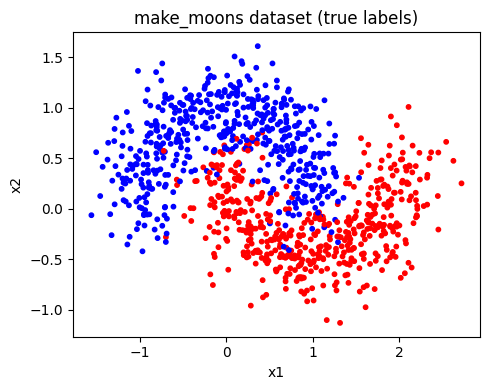

In [2]:
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons dataset (true labels)")
plt.tight_layout()
plt.show()


Cell 3 – Self‑training function

In [3]:
def self_training(X_labeled, y_labeled, X_unlabeled, base_model,
                  threshold=0.9, max_iter=10):
    model = base_model
    X_l = X_labeled.copy()
    y_l = y_labeled.copy()
    X_u = X_unlabeled.copy()

    added_per_iter = []

    for i in range(max_iter):
        model.fit(X_l, y_l)

        if len(X_u) == 0:
            print(f"Iteration {i}: no unlabeled data left.")
            break

        proba = model.predict_proba(X_u)
        confidence = proba.max(axis=1)
        y_u_pred = proba.argmax(axis=1)
        confident_idx = np.where(confidence >= threshold)[0]
        print(f"Iteration {i}: {len(confident_idx)} high-confidence points "
              f"(labeled so far: {len(y_l)})")

        added_per_iter.append(len(confident_idx))

        if len(confident_idx) == 0:
            print("No more confident points; stopping.")
            break

        X_l = np.vstack((X_l, X_u[confident_idx]))
        y_l = np.hstack((y_l, y_u_pred[confident_idx]))
        X_u = np.delete(X_u, confident_idx, axis=0)

    return model, X_l, y_l, X_u, added_per_iter


Cell 4 – Baseline RF without self‑training

In [4]:
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=None,
                                     random_state=42)
rf_baseline.fit(X_labeled, y_labeled)
y_pred_base = rf_baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print("Initially labeled count:", len(y_labeled))
print("Initially unlabeled count:", len(X_unlabeled))
print(f"Baseline RF accuracy (no self-training): {acc_base:.3f}")


Initially labeled count: 100
Initially unlabeled count: 700
Baseline RF accuracy (no self-training): 0.940


Cell 5 – Run self‑training for multiple thresholds

In [5]:
thresholds = [0.8, 0.9, 0.95]
results = []

for thr in thresholds:
    print("\n==============================")
    print(f"Self-training with threshold = {thr}")
    print("==============================")

    base_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                        random_state=42)

    rf_thr, X_l_thr, y_l_thr, X_u_thr, added_thr = self_training(X_labeled,
                                                                 y_labeled,
                                                                 X_unlabeled,
                                                                 base_model,
                                                                 threshold=thr,
                                                                 max_iter=10)

    acc_thr = accuracy_score(y_test, rf_thr.predict(X_test))

    print(f"Threshold {thr}: acc = {acc_thr:.3f}, "
          f"final labeled = {len(y_l_thr)}, "
          f"remaining unlabeled = {len(X_u_thr)}, "
          f"added per iter = {added_thr}")

    results.append((thr, acc_thr, len(y_l_thr), len(X_u_thr), added_thr))



Self-training with threshold = 0.8
Iteration 0: 569 high-confidence points (labeled so far: 100)
Iteration 1: 60 high-confidence points (labeled so far: 669)
Iteration 2: 17 high-confidence points (labeled so far: 729)
Iteration 3: 13 high-confidence points (labeled so far: 746)
Iteration 4: 10 high-confidence points (labeled so far: 759)
Iteration 5: 5 high-confidence points (labeled so far: 769)
Iteration 6: 0 high-confidence points (labeled so far: 774)
No more confident points; stopping.
Threshold 0.8: acc = 0.955, final labeled = 774, remaining unlabeled = 26, added per iter = [569, 60, 17, 13, 10, 5, 0]

Self-training with threshold = 0.9
Iteration 0: 414 high-confidence points (labeled so far: 100)
Iteration 1: 77 high-confidence points (labeled so far: 514)
Iteration 2: 32 high-confidence points (labeled so far: 591)
Iteration 3: 28 high-confidence points (labeled so far: 623)
Iteration 4: 22 high-confidence points (labeled so far: 651)
Iteration 5: 17 high-confidence points (

Cell 6 – Compare accuracies in a small table

In [6]:
print("\nSummary (including baseline):")
print(f"Baseline (no self-training): acc = {acc_base:.3f}, "
      f"labeled = {len(y_labeled)}")

for thr, acc_thr, n_lab, n_unlab, added in results:
    print(f"Threshold {thr}: acc = {acc_thr:.3f}, "
          f"labeled = {n_lab}, remaining unlabeled = {n_unlab}, "
          f"added per iter = {added}")



Summary (including baseline):
Baseline (no self-training): acc = 0.940, labeled = 100
Threshold 0.8: acc = 0.955, labeled = 774, remaining unlabeled = 26, added per iter = [569, 60, 17, 13, 10, 5, 0]
Threshold 0.9: acc = 0.935, labeled = 694, remaining unlabeled = 106, added per iter = [414, 77, 32, 28, 22, 17, 1, 3, 0]
Threshold 0.95: acc = 0.940, labeled = 562, remaining unlabeled = 238, added per iter = [299, 81, 46, 27, 7, 1, 1, 0]


Cell 7 – Before vs after plots for one chosen threshold

Iteration 0: 414 high-confidence points (labeled so far: 100)
Iteration 1: 77 high-confidence points (labeled so far: 514)
Iteration 2: 32 high-confidence points (labeled so far: 591)
Iteration 3: 28 high-confidence points (labeled so far: 623)
Iteration 4: 22 high-confidence points (labeled so far: 651)
Iteration 5: 17 high-confidence points (labeled so far: 673)
Iteration 6: 1 high-confidence points (labeled so far: 690)
Iteration 7: 3 high-confidence points (labeled so far: 691)
Iteration 8: 0 high-confidence points (labeled so far: 694)
No more confident points; stopping.
Chosen threshold 0.9: acc = 0.935
Pseudo-labels added per iteration: [414, 77, 32, 28, 22, 17, 1, 3, 0]


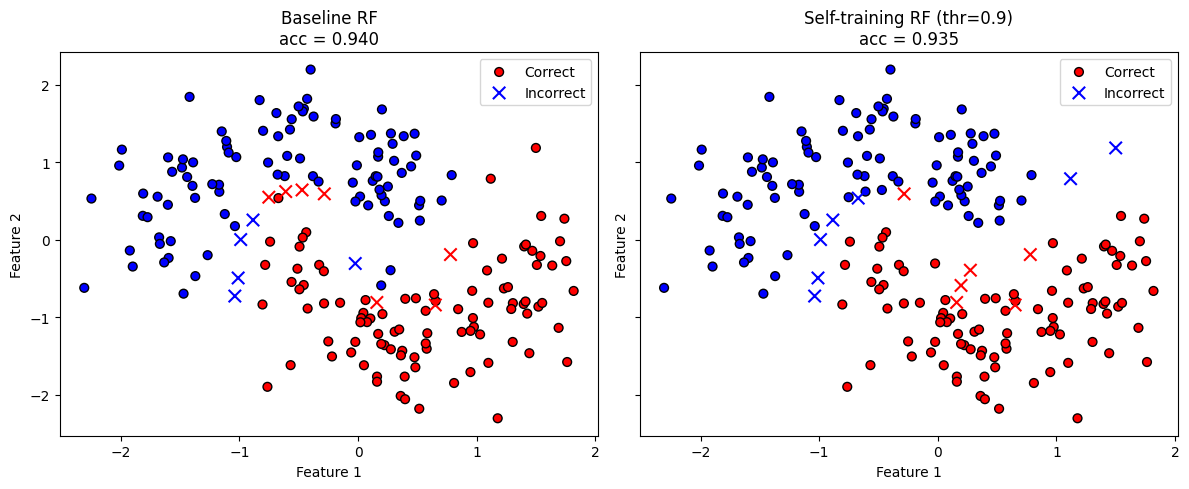

In [7]:
chosen_thr = 0.9

base_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                    random_state=42)
rf_self, X_l_final, y_l_final, X_u_final, added_per_iter = self_training(
    X_labeled, y_labeled, X_unlabeled, base_model,threshold=chosen_thr,
    max_iter=10)

y_pred_self = rf_self.predict(X_test)
acc_self = accuracy_score(y_test, y_pred_self)

print(f"Chosen threshold {chosen_thr}: acc = {acc_self:.3f}")
print("Pseudo-labels added per iteration:", added_per_iter)

def plot_predictions(X, y_true, y_pred, title, ax):
    correct = y_pred == y_true
    incorrect = ~correct

    ax.scatter(X[correct, 0],X[correct, 1],c=y_pred[correct],cmap="bwr",
               marker="o",edgecolor="k",s=40,label="Correct")
    if incorrect.any():
        ax.scatter(X[incorrect, 0],X[incorrect, 1],c=y_pred[incorrect],
                   cmap="bwr",marker="x",s=80,label="Incorrect")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.legend(loc="best")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_predictions(X_test, y_test, y_pred_base,
                 f"Baseline RF\nacc = {acc_base:.3f}", axes[0])
plot_predictions(X_test, y_test, y_pred_self,
                 f"Self-training RF (thr={chosen_thr})\nacc = {acc_self:.3f}",
                 axes[1])

plt.tight_layout()
plt.show()
